# Set Builders Guide

Learn how to describe regions in space with **SetBuilders**, evaluate them on a backend grid, and plot the result.

Run the **Setup** cell first, then each section in order. You can copy the code into your own scripts.

---

## What you will learn

1. What a **SetBuilder** is and how **`Out = S(impl)`** produces a grid array
2. Basic shapes: `HalfSpaceSet`, `AlignedBoxSet`, and combinations
3. How to **visualize** results with `plot3d` / `plot2d` helpers

**Not covered here:** temporal logic (`TLT`), `BallSet`, `CylinderSet`.

---

## Workflow (every example)

| Step | Action | Example |
|------|--------|---------|
| 1 | **Describe** | `S = AlignedBoxSet(...)` |
| 2 | **Realize** | `Out = S(impl)` |
| 3 | **Visualize** | `plot3d(Out, title='...')` |


## Setup

**Goal:** create a backend (`TVHJImpl`) and small helpers (`plot3d`, `plot2d`) used in the examples below.

- The state grid is `(t, x, y, yaw)` with **Air3d** dynamics.
- When you only constrain `x` and `y`, the set does not depend on `yaw`.
- 3D plots use axes `(x, y, yaw)` - the shape looks like a prism along `yaw`.


In [1]:
from math import pi

import numpy as np
from IPython.display import Image, display
from pyspect import Inter, Union, Compl
from pyspect.set_builder import AlignedBoxSet, HalfSpaceSet
from pyspect.impls.hj_reachability import TVHJImpl
from pyspect.systems.hj_reachability import Air3d

AXES = [
    dict(name='t', bounds=[0, 1], step=1.0, unit='s'),
    dict(name='x', bounds=[-5, +5], points=25, unit='m'),
    dict(name='y', bounds=[-5, +5], points=25, unit='m'),
    dict(name='yaw', bounds=[-pi, +pi], points=12, unit='rad'),
]
impl = TVHJImpl(dict(cls=Air3d), AXES)

print('Axes :', [impl.axis_name(i) for i in range(impl.ndim)])
print('Shape:', impl.shape, '  (t, x, y, yaw)')


def fix_t(vf, t=0):
    """Pick one time slice; broadcast to full grid shape (needed for plotting)."""
    vf4d = np.array(vf[t : t + 1, ...])
    return np.broadcast_to(vf4d, (1,) + tuple(impl.shape[1:])).copy()


def _show_png(fig, width=800, height=500):
    """Display the figure as a PNG image below the cell."""
    import warnings

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", DeprecationWarning)
        png = fig.to_image(format="png", width=width, height=height)
    display(Image(png))


def plot3d(out, title=''):
    """Step 3 - 3D isosurface in (x, y, yaw)."""
    fig = impl.plot(
        fix_t(out),
        method='isosurface',
        axes=('x', 'y', 'yaw'),
        layout_title=title,
        layout_height=500,
    )
    _show_png(fig, width=800, height=500)


def plot2d(out, title=''):
    """Step 3 - 2D bitmap slice in the (x, y) plane."""
    fig = impl.plot(
        fix_t(out),
        method='bitmap',
        axes=('x', 'y'),
        layout_title=title,
        layout_height=480,
    )
    _show_png(fig, width=720, height=480)


Axes : ['t', 'x', 'y', 'yaw']
Shape: (2, 25, 25, 12)   (t, x, y, yaw)


---

## Warm-up: your first shape

**Goal:** run the full three-step workflow once before the detailed sections.

**Takeaway:** a SetBuilder is a *description*; `S(impl)` turns it into a boolean array on the grid that you can plot.


Out.shape : (2, 25, 25, 12)
  -> (t, x, y, yaw) on the grid
Requires  : ('intersect', 'halfspace', 'complement')


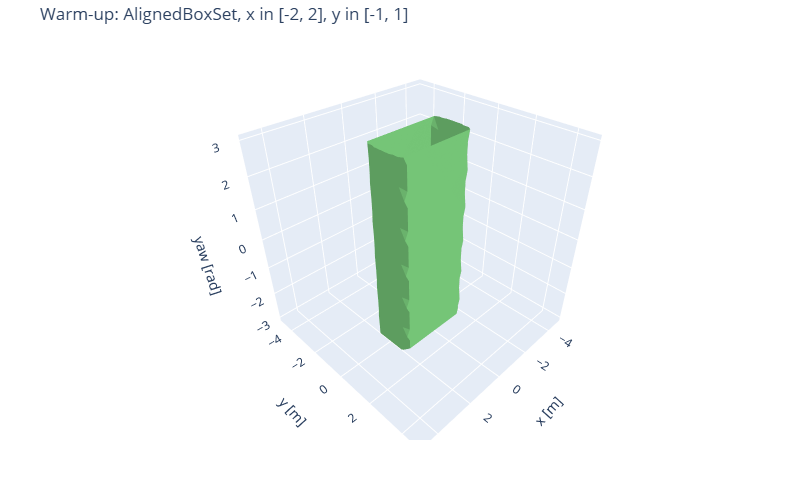

In [2]:
# Step 1 - describe
S = AlignedBoxSet(x=(-2, 2), y=(-1, 1))

# Step 2 - realize
Out = S(impl)
print('Out.shape :', Out.shape)
print('  -> (t, x, y, yaw) on the grid')
print('Requires  :', S.__require__)

# Step 3 - visualize
plot3d(Out, title='Warm-up: AlignedBoxSet, x in [-2, 2], y in [-1, 1]')


---

## 1. HalfSpaceSet - one half-plane

**Goal:** keep points on one side of a line (one linear inequality).

Parameters:
- `normal` - vector pointing **into** the allowed region
- `offset` - any point on the boundary line
- `axes` - which coordinates are constrained (here `x` and `y` only)

**Takeaway:** one `HalfSpaceSet` = one wall / one linear constraint.


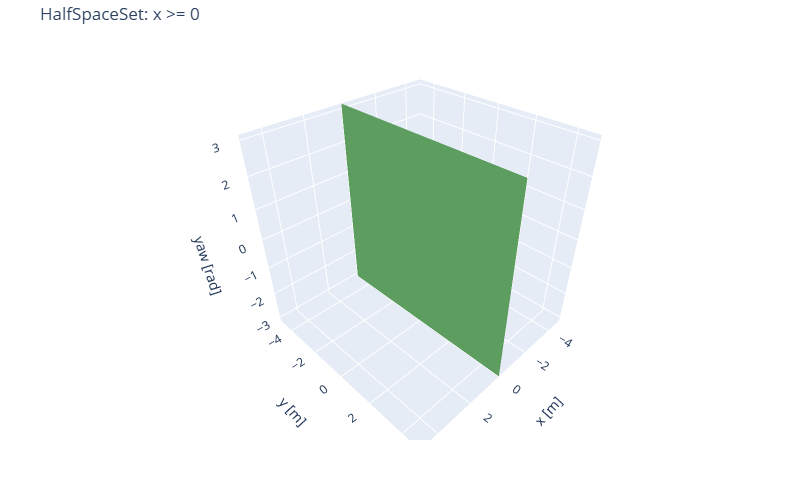

In [3]:
# Example A - vertical wall: x >= 0
H = HalfSpaceSet(normal=[1, 0], offset=[0, 0], axes=['x', 'y'])
Out = H(impl)
plot3d(Out, title='HalfSpaceSet: x >= 0')


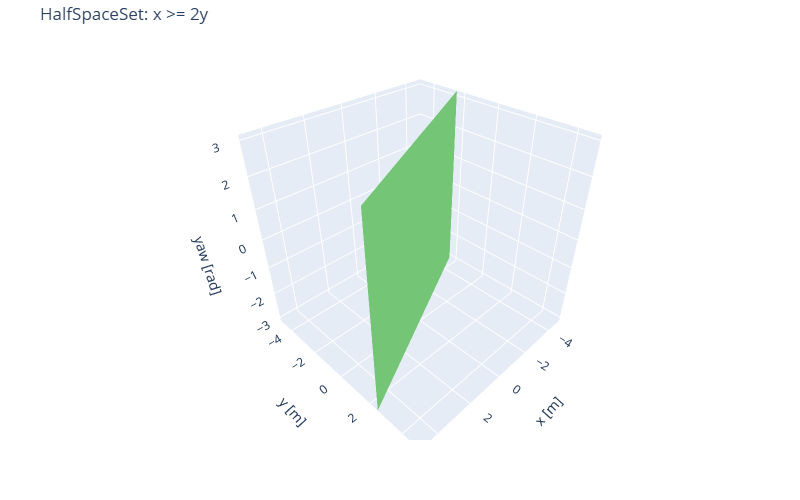

In [4]:
# Example B - oblique wall: x >= 2y  (normal [1, -2])
H = HalfSpaceSet(normal=[1, -2], offset=[0, 0], axes=['x', 'y'])
Out = H(impl)
plot3d(Out, title='HalfSpaceSet: x >= 2y')


---

## 2. AlignedBoxSet - axis-aligned box

**Goal:** describe a rectangle with simple bounds - the most common shape.

**Takeaway:** use `AlignedBoxSet` when bounds align with the grid axes.
Internally it is built from half-spaces (see [section 6](#6-under-the-hood-alignedboxset-as-four-half-spaces)).


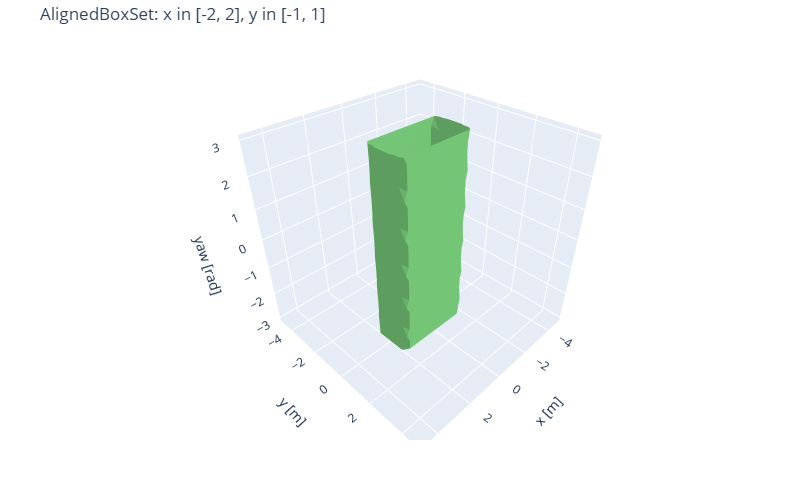

In [5]:
BOX = AlignedBoxSet(x=(-2, 2), y=(-1, 1))
Out = BOX(impl)
plot3d(Out, title='AlignedBoxSet: x in [-2, 2], y in [-1, 1]')


---

## 3. Combining shapes - `Inter`, `Union`, `Compl`

**Goal:** build richer regions from simple pieces.

| Operator | Meaning |
|----------|---------|
| `Inter(A, B)` | inside **both** A and B |
| `Union(A, B)` | inside **either** A or B |
| `Compl(A)` | **outside** A |

On `TVHJImpl`, `Inter` and `Union` take **two** builders at a time - nest them for three or more.
The complement operator is named **`Compl`** (not `Complement`).


### 3a. Inter - trim a box (x <= 1)

**Takeaway:** intersection = keep only points that satisfy **every** constraint.


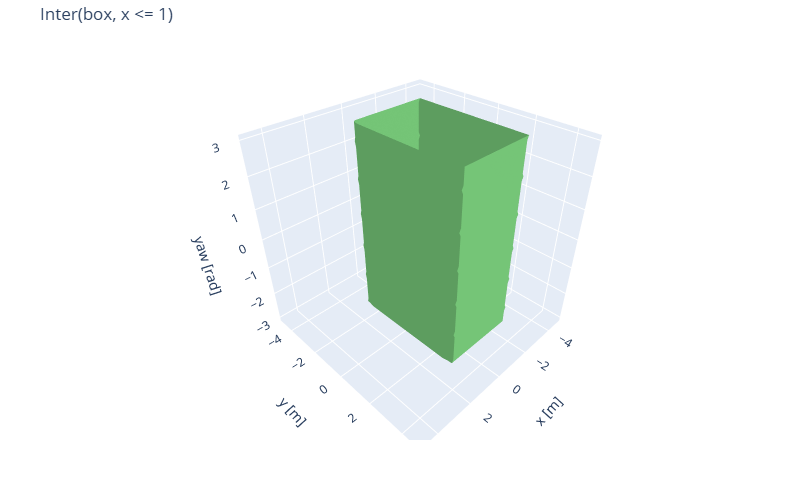

In [6]:
base = AlignedBoxSet(x=(-3, 3), y=(-3, 3))
cut = HalfSpaceSet(normal=[-1, 0], offset=[1, 0], axes=['x', 'y'])  # x <= 1
Out = Inter(base, cut)(impl)
plot3d(Out, title='Inter(box, x <= 1)')


### 3b. Union - two separate boxes

**Takeaway:** union = a point is allowed if it lies in **either** region.


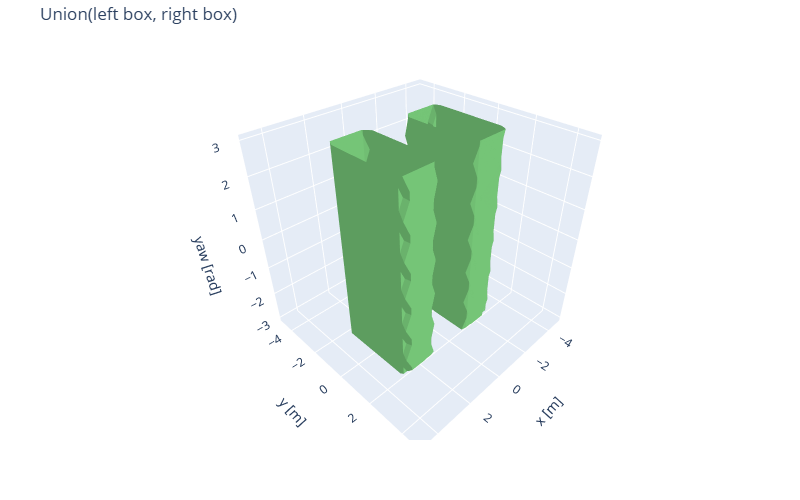

In [7]:
left = AlignedBoxSet(x=(-3, -1), y=(-2, 2))
right = AlignedBoxSet(x=(1, 3), y=(-2, 2))
Out = Union(left, right)(impl)
plot3d(Out, title='Union(left box, right box)')


### 3c. Compl - box with a hole

**Takeaway:** `Compl` removes an inner region; combine with `Inter` to cut holes.


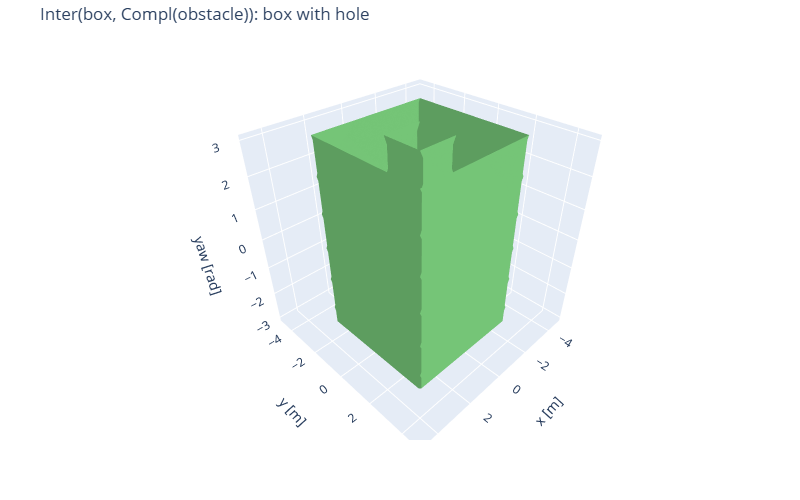

In [8]:
outer = AlignedBoxSet(x=(-3, 3), y=(-3, 3))
obstacle = AlignedBoxSet(x=(-1, 1), y=(-1, 1))
Out = Inter(outer, Compl(obstacle))(impl)
plot3d(Out, title='Inter(box, Compl(obstacle)): box with hole')


---

## 4. Slab - band between two parallel walls

**Goal:** model a corridor with fixed width along one direction.

A **slab** is an `Inter` of two opposing half-spaces. Here: `-1 <= x <= 1`.

**Takeaway:** two parallel `HalfSpaceSet` walls form an infinite strip / band.


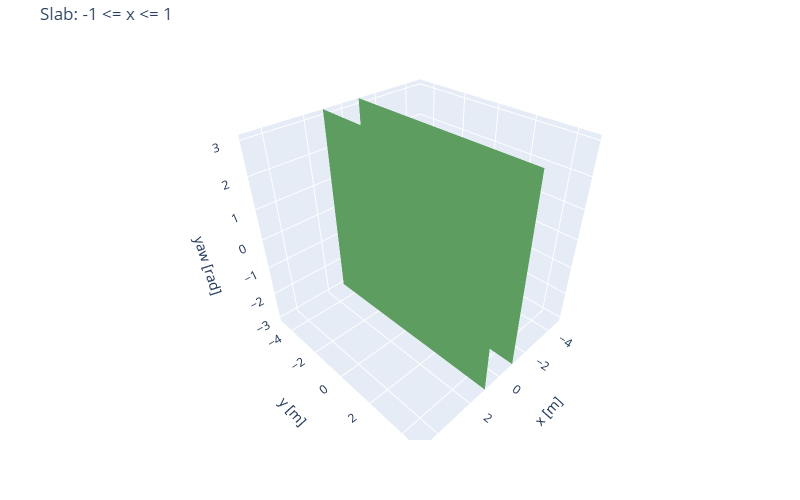

In [9]:
SLAB = Inter(
    HalfSpaceSet(normal=[1, 0], offset=[-1, 0], axes=['x', 'y']),
    HalfSpaceSet(normal=[-1, 0], offset=[1, 0], axes=['x', 'y']),
)
Out = SLAB(impl)
plot3d(Out, title='Slab: -1 <= x <= 1')


---

## 5. 2D plot - flat slice in (x, y)

**Goal:** view the shape in the plane instead of a 3D isosurface.

**Takeaway:** use `method='bitmap'` with `axes=('x', 'y')` for a top-down 2D view.


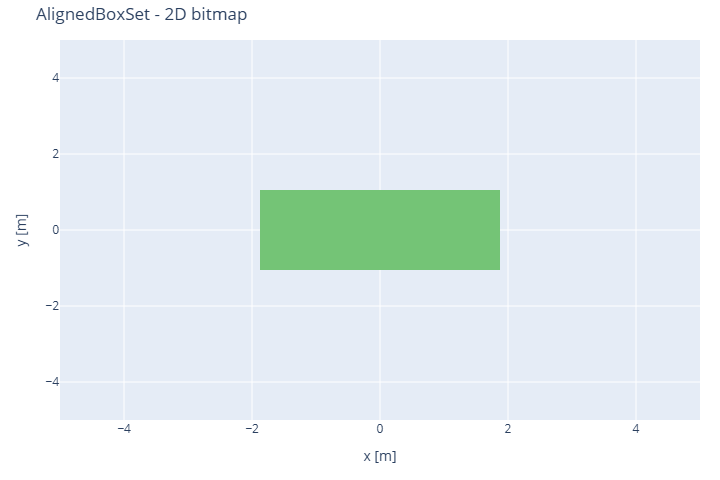

In [10]:
Out = AlignedBoxSet(x=(-2, 2), y=(-1, 1))(impl)
plot2d(Out, title='AlignedBoxSet - 2D bitmap')


---

## 6. Under the hood - AlignedBoxSet as four half-spaces

**Goal:** understand how `AlignedBoxSet` relates to `HalfSpaceSet` (optional section).

A box `x in [-2, 2], y in [-2, 2]` is exactly the `Inter` of four `HalfSpaceSet` walls.
The numeric check below should print `0.0`.


In [11]:
box_aligned = AlignedBoxSet(x=(-2, 2), y=(-2, 2))(impl)

box_manual = Inter(
    HalfSpaceSet(normal=[1, 0], offset=[-2, 0], axes=['x', 'y']),
    Inter(
        HalfSpaceSet(normal=[-1, 0], offset=[2, 0], axes=['x', 'y']),
        Inter(
            HalfSpaceSet(normal=[0, 1], offset=[0, -2], axes=['x', 'y']),
            HalfSpaceSet(normal=[0, -1], offset=[0, 2], axes=['x', 'y']),
        ),
    ),
)(impl)

diff = float(np.max(np.abs(box_aligned - box_manual)))
print(f'max |AlignedBoxSet - Inter(4 HalfSpaceSet)| = {diff:.6f}')
assert diff == 0.0, 'Expected exact match'
print('OK - AlignedBoxSet is built from half-spaces internally.')


max |AlignedBoxSet - Inter(4 HalfSpaceSet)| = 0.000000
OK - AlignedBoxSet is built from half-spaces internally.


---

## Recap - which builder should I use?

| Goal | Use |
|------|-----|
| Single linear constraint | `HalfSpaceSet` |
| Axis-aligned box | `AlignedBoxSet` |
| Band / corridor | `Inter` of two `HalfSpaceSet` |
| Convex polygon | nested `Inter` of `HalfSpaceSet` |
| Combine / cut / holes | `Inter`, `Union`, `Compl` |

**Not on `TVHJImpl` today:** `BallSet`, `CylinderSet`.

---

**Next steps**

- [Set Builders API reference](../reference/set_builder.md) for the full API
- [Get Started](../get_started.md) for installation and your first spec
